# Experiment 12.0 — Local Primitive Bottleneck

Analysis-only notebook. Training and post-hoc extraction are performed by the Slurm workflow; this notebook reads finalized CSV artifacts.


In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
ART = ROOT / 'notebooks' / 'artifacts' / 'experiment_12_0_local_primitive_bottleneck' / 'local_primitive_bottleneck_v1'
dense = pd.read_csv(ART / 'dense_runs.csv')
dense_summary = pd.read_csv(ART / 'dense_summary.csv')
posthoc = pd.read_csv(ART / 'posthoc_runs.csv')
posthoc_summary = pd.read_csv(ART / 'posthoc_summary.csv')
dense_summary


,temporal_mode,method,test_ba_mean,test_ba_std,l2_wholecount_probe_test_ba_mean,l2_fixed250_probe_test_ba_mean,primitive_effective_k_mean
0,t0,r0b_analog,0.510827,0.024332,0.586273,0.579424,9.339940
1,t0,r1_what,0.497984,0.016981,0.586273,0.587253,11.787319
2,t0,r2_main_frozen,0.496436,0.022491,0.586273,0.587253,10.982604
3,t0,r2_main_e2e,0.513782,0.016889,0.584925,0.579598,11.091921
4,raw,r0b_analog,0.437602,0.062615,0.586273,0.579424,8.520840
5,raw,r1_what,0.472386,0.058014,0.586273,0.587253,10.320403
6,raw,r2_main_frozen,0.464321,0.059200,0.586273,0.587253,5.153277
7,raw,r2_main_e2e,0.468559,0.066148,0.569748,0.591212,5.122350
8,ema,r0b_analog,0.473647,0.041240,0.586273,0.579424,8.245665
9,ema,r1_what,0.470166,0.028356,0.586273,0.587253,11.013305


## Dense T0 / RAW / EMA comparison


In [4]:
dense_summary.sort_values(['method', 'temporal_mode'])[['temporal_mode','method','test_ba_mean','test_ba_std','l2_fixed250_probe_test_ba_mean','l2_wholecount_probe_test_ba_mean','primitive_effective_k_mean']]


,temporal_mode,method,test_ba_mean,test_ba_std,l2_fixed250_probe_test_ba_mean,l2_wholecount_probe_test_ba_mean,primitive_effective_k_mean
8,ema,r0b_analog,0.473647,0.041240,0.579424,0.586273,8.245665
4,raw,r0b_analog,0.437602,0.062615,0.579424,0.586273,8.520840
0,t0,r0b_analog,0.510827,0.024332,0.579424,0.586273,9.339940
9,ema,r1_what,0.470166,0.028356,0.587253,0.586273,11.013305
5,raw,r1_what,0.472386,0.058014,0.587253,0.586273,10.320403
1,t0,r1_what,0.497984,0.016981,0.587253,0.586273,11.787319
11,ema,r2_main_e2e,0.518959,0.011537,0.570326,0.562376,9.820405
7,raw,r2_main_e2e,0.468559,0.066148,0.591212,0.569748,5.122350
3,t0,r2_main_e2e,0.513782,0.016889,0.579598,0.584925,11.091921
10,ema,r2_main_frozen,0.467297,0.016593,0.587253,0.586273,9.794333


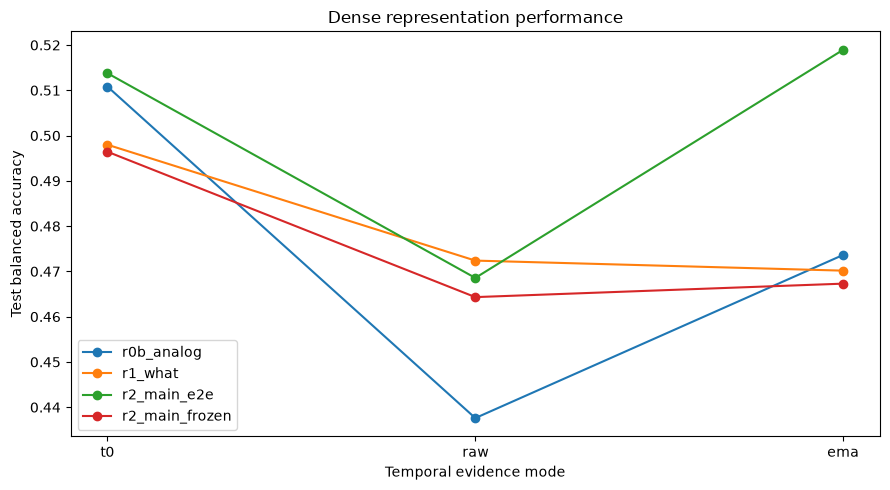

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
for method, frame in dense.groupby('method'):
    means = frame.groupby('temporal_mode', sort=False)['test_ba'].mean().reindex(['t0','raw','ema'])
    ax.plot(means.index, means.values, marker='o', label=method)
ax.set_xlabel('Temporal evidence mode')
ax.set_ylabel('Test balanced accuracy')
ax.set_title('Dense representation performance')
ax.legend()
fig.tight_layout()


## Fixed-transform R0 → R2 diagnosis


In [6]:
fixed_names = ['r0_direct_l2','r0a_integrated_128d','r0b_analog_16d','r1_main_what_posthoc','r2_main_activity_x_what_posthoc','r1_legacy_raw_softmax_posthoc','r2_legacy_rms_x_raw_softmax_posthoc']
fixed = posthoc[posthoc['representation'].isin(fixed_names)]
fixed.groupby(['temporal_mode','representation'], sort=False)['test_ba'].agg(['mean','std']).reset_index()


,temporal_mode,representation,mean,std
0,t0,r0_direct_l2,0.586273,0.009744
1,t0,r0a_integrated_128d,0.586273,0.009744
2,t0,r0b_analog_16d,0.510733,0.011566
3,t0,r1_main_what_posthoc,0.496563,0.018685
4,t0,r2_main_activity_x_what_posthoc,0.519840,0.043135
5,t0,r1_legacy_raw_softmax_posthoc,0.529309,0.014631
6,t0,r2_legacy_rms_x_raw_softmax_posthoc,0.532947,0.022837
7,raw,r0_direct_l2,0.586273,0.009744
8,raw,r0a_integrated_128d,0.525435,0.012077
9,raw,r0b_analog_16d,0.472186,0.096675


## R3/R4 sparsity–accuracy trade-off


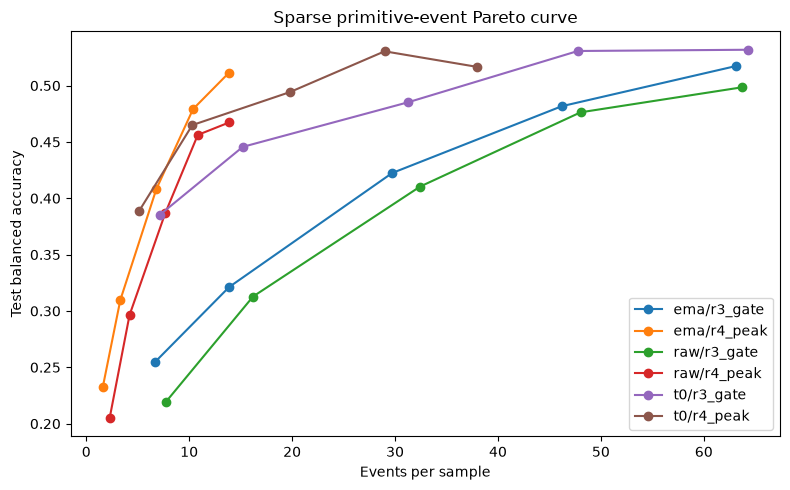

In [7]:
sparse = posthoc[posthoc['representation'].isin(['r3_gate','r4_peak'])].copy()
fig, ax = plt.subplots(figsize=(8, 5))
for (mode, rep), frame in sparse.groupby(['temporal_mode','representation']):
    summary = frame.groupby('quantile').agg(test_ba=('test_ba','mean'), events=('events_per_sample_test_mean','mean')).reset_index()
    ax.plot(summary['events'], summary['test_ba'], marker='o', label=f'{mode}/{rep}')
ax.set_xlabel('Events per sample')
ax.set_ylabel('Test balanced accuracy')
ax.set_title('Sparse primitive-event Pareto curve')
ax.legend()
fig.tight_layout()


## Token/shortcut diagnostics


In [8]:
diagnostic_names = ['r2_dense','r2_hard_token','magnitude_only','r4_count_only']
posthoc[posthoc['representation'].isin(diagnostic_names)].groupby(['temporal_mode','source_method','representation'], sort=False)['test_ba'].agg(['mean','std']).reset_index()


,temporal_mode,source_method,representation,mean,std
0,t0,r2_main_frozen,r2_dense,0.534768,0.006157
1,t0,r2_main_frozen,r2_hard_token,0.481802,0.018560
2,t0,r2_main_frozen,magnitude_only,0.149728,0.019925
3,t0,r2_main_frozen,r4_count_only,0.171813,0.023941
4,t0,r2_main_e2e,r2_dense,0.536201,0.027385
5,t0,r2_main_e2e,r2_hard_token,0.480197,0.014708
6,t0,r2_main_e2e,magnitude_only,0.150000,0.020672
7,t0,r2_main_e2e,r4_count_only,0.158860,0.022028
8,raw,r2_main_frozen,r2_dense,0.496152,0.046310
9,raw,r2_main_frozen,r2_hard_token,0.336643,0.080147
